# Exploration plotting
The purpose of this notebook is to plot exploration behaviour. We do that by plotting the number of actions explored per turn and the proportion of greedy pulls per turn

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


In [2]:
# Move up to main repo directory
import os
os.chdir("../..") # ONLY RUN THIS ONCE

In [3]:
## Load CSV file from file path string

def load_csv(file_path):
    """Load a CSV file and return a pandas DataFrame."""
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded CSV file: {file_path}")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

### Lookup Maps for Plots

In [4]:
rewards_per_scale = {
    'high_scale': [75,50,25],
    'low_scale': [0.75,0.5,0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale': [-0.25, -0.5, -0.75]
}

## Plotting

In [5]:

###############
# Styling constants and such
###############

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'firebrick',
        'label': 'Minimum',
    },
    'high_neg_scale': {
        'linestyle': '-',
        'color': 'crimson',
        'label': 'Negative High',
        'marker': '^',
    },
    'low_neg_scale': {
        'linestyle': '-',
        'color': 'salmon',
        'label': 'Negative Low',
        'marker': 'v',
    },
    'high_scale': {
        'linestyle': '-',
        'color': 'darkgreen',
        'label': 'Positive High',
        'marker': '^',
    },
    'low_scale': {
        'linestyle': '-',
        'color': 'palegreen',
        'label': 'Positive Low',
        'marker': 'v',
    },
}

In [11]:

## First, we load in the merged dataframe
eval_path = 'experiments/merged_eval_results.csv'
results_df = load_csv(eval_path)

scale_label = 'scale'
nom_label = 'nomenclature'

# metrics = ['cum_regret', 'sem_optimal_actions', 'reward_optimal_actions']
metrics = ['step_regret', 'cum_regret', 'greedy_probs', 'exploration_count']
model = 'Qwen14B'
hist = 'Summarized'
variance = 'No'


subset = results_df[(results_df['Model'] == model) & (results_df['History'] == hist) & (results_df['Variance'] == variance)]

#  Define your desired order of keys in the legend
legend_order = ['max_val', 'min_val', 'high_scale', 'high_neg_scale', 'low_scale', 'low_neg_scale']

# Hardcoded row of 3 subplots for nomenclatures
nomenclatures = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead']

Loaded CSV file: experiments/merged_eval_results.csv


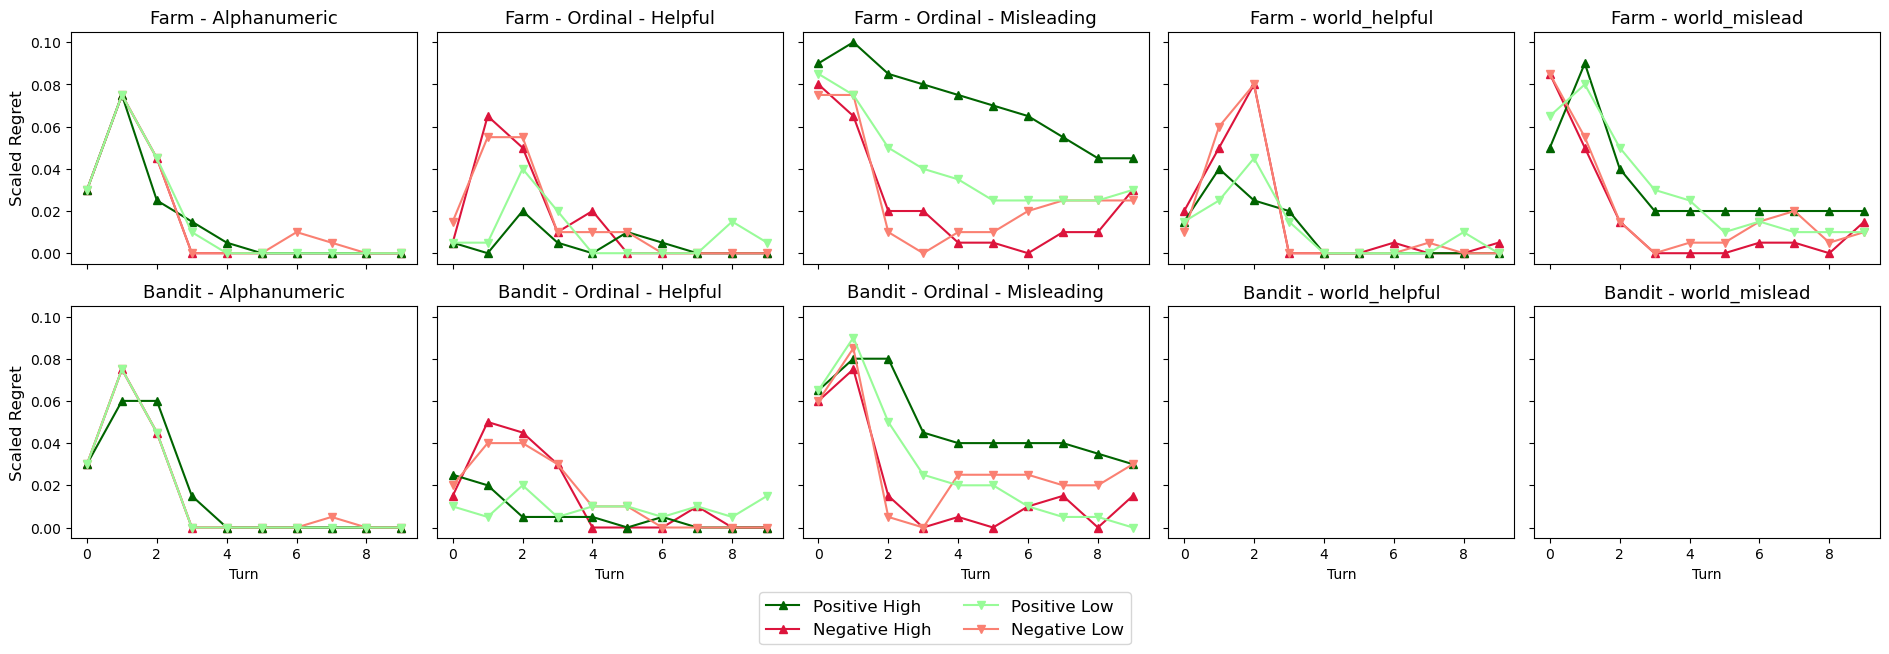

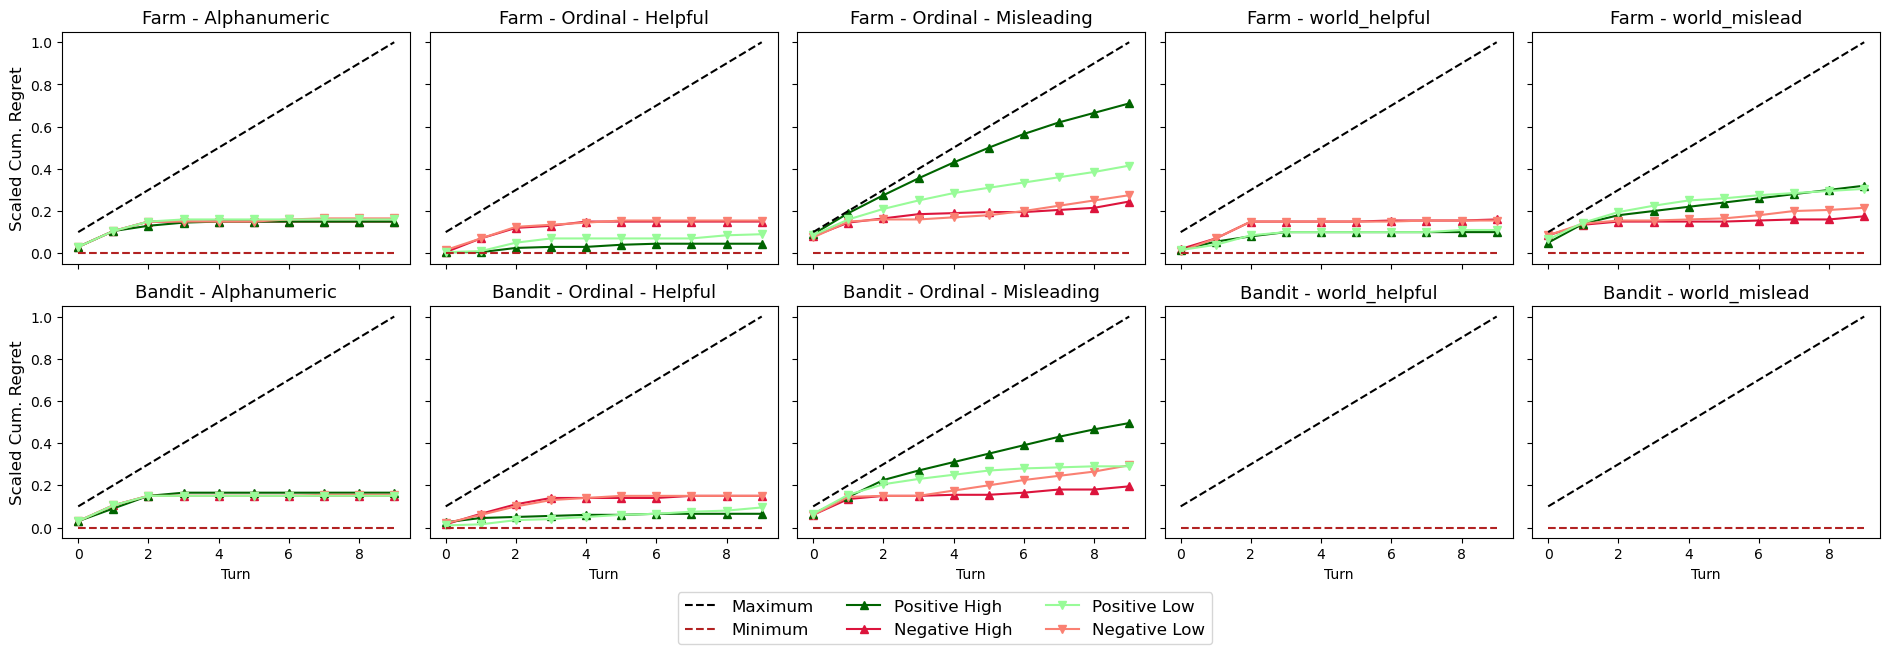

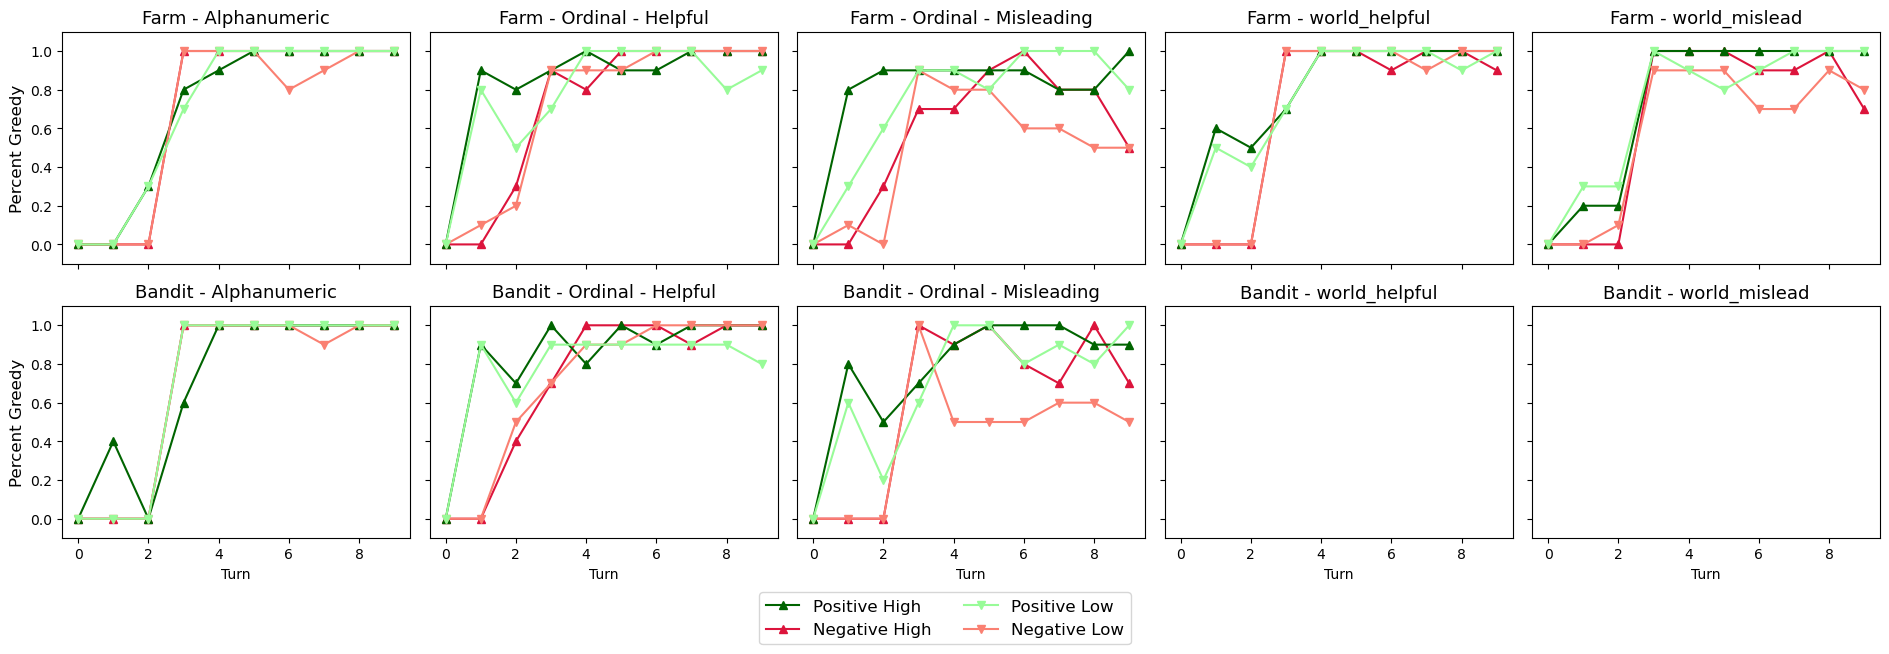

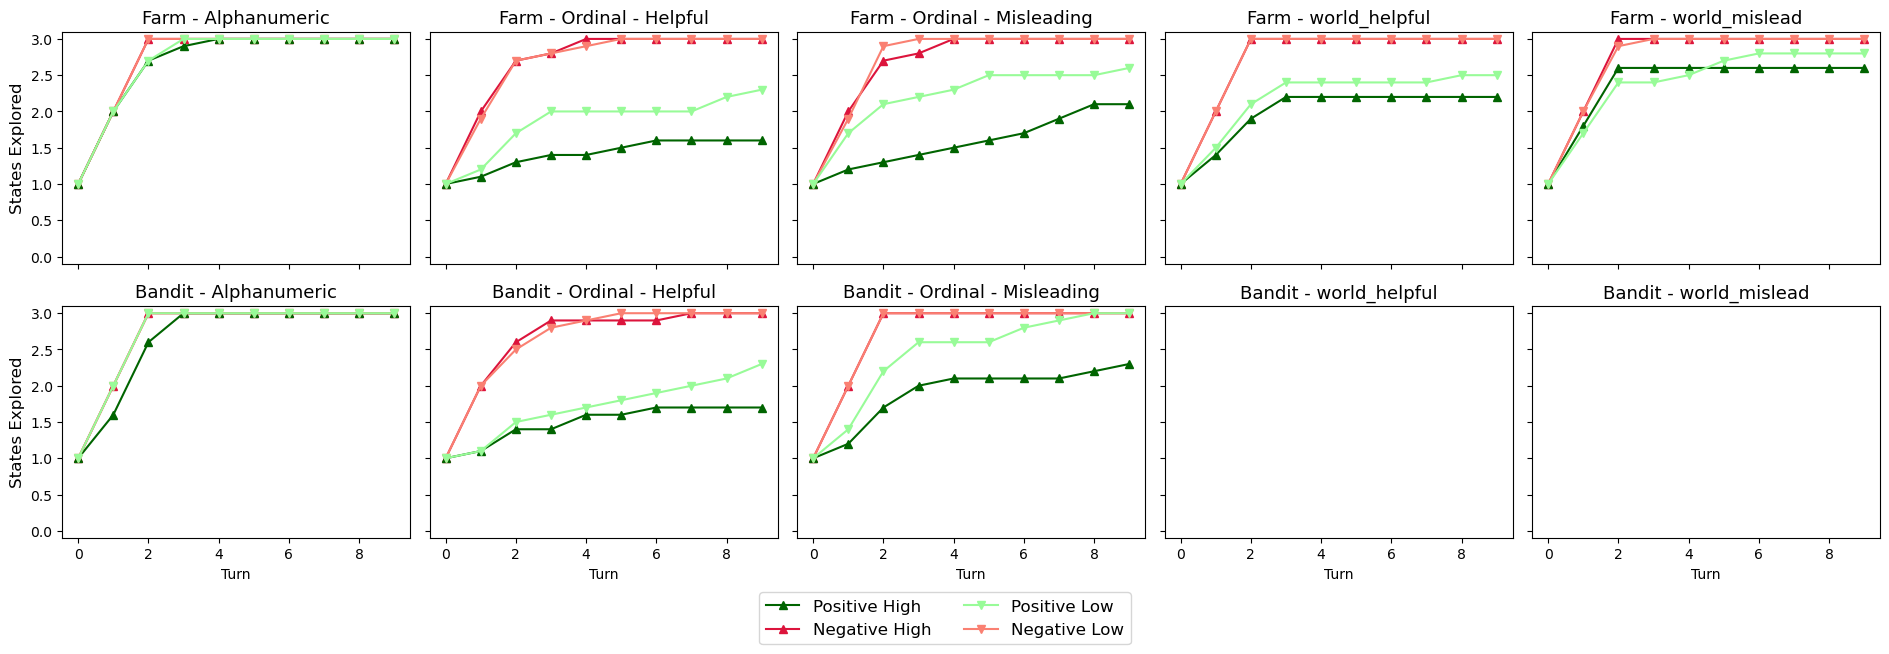

In [13]:
# Map nomenclature values to official names for titles
nomenclature_map = {
    'Bandit': {
        'alphanumeric': 'Alphanumeric',
        'ordinal_helpful': 'Ordinal - Helpful',
        'ordinal_mislead': 'Ordinal - Misleading',
        'sent_mislead': 'Sentiment - Misleading',
        'sent_helpful': 'Sentiment - Helpful',
    },
    'Farm': {
        'alphanumeric': 'Alphanumeric',
        'ordinal_helpful': 'Ordinal - Helpful',
        'ordinal_mislead': 'Ordinal - Misleading',
        'sent_mislead': 'Sentiment - Misleading',
        'sent_helpful': 'Sentiment - Helpful',
    },
}

metric_map = {
    'step_regret': "Scaled Regret",
    'cum_regret': "Scaled Cum. Regret",
    'greedy_probs': 'Percent Greedy',
    'exploration_count': 'States Explored'
}

# New order: Helpful, Alphanumeric, Misleading
# nomenclatures = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead', 'sent_helpful', 'sent_mislead']
nomenclatures = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead']
domains = list(results_df['Domain'].unique())

for metric_name in metrics:
    fig, axes = plt.subplots(len(domains), len(nomenclatures), figsize=(19, 7), sharex=True, sharey=True)

    label_to_handle = {}
    label_to_key = {STYLE_CONSTANTS[k]['label']: k for k in legend_order if k in STYLE_CONSTANTS}
    legend_labels_set = set()

    for row_idx, domain in enumerate(domains):
        for col_idx, subplot_kwd in enumerate(nomenclatures):
            ax = axes[row_idx, col_idx]
            domain_subset = subset[subset['Domain'] == domain]
            filtered_df = domain_subset[domain_subset['nomenclature'].str.contains(subplot_kwd, na=False)].copy()

            turn_numbers = sorted(
                int(col.split('_')[-2]) for col in domain_subset.columns 
                if col.startswith(f"{metric_name}_") and col.endswith("_mean")
)

            for scale_label in filtered_df['scale'].unique():
                scale_df = filtered_df[filtered_df['scale'] == scale_label]
                means = scale_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
                stds = scale_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

                if metric_name in ['step_regret', "cum_regret"]:
                    normalizing_constant = (max(rewards_per_scale[scale_label]) - min(rewards_per_scale[scale_label])) * len(means)
                    means = [x / normalizing_constant for x in means]
                    stds = [x / normalizing_constant for x in stds]

                try:
                    handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[scale_label])
                    label = STYLE_CONSTANTS[scale_label]['label']
                    if label not in label_to_handle:
                        label_to_handle[label] = handle
                        legend_labels_set.add(label)
                except Exception as e:
                    print(f"ERROR: {scale_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {scale_df}", e)

            # Add upper and lower bounds
            if metric_name == "cum_regret":
                regret_lists = {}
                max_step_regret = 1.0 / len(turn_numbers) if len(turn_numbers) > 0 else 0
                regret_lists['max_val'] = np.linspace(max_step_regret, 1.0, len(turn_numbers)) if len(turn_numbers) > 0 else []
                regret_lists['min_val'] = [0.0] * len(turn_numbers)

                for metric_key in regret_lists.keys():
                    if len(turn_numbers) == len(regret_lists[metric_key]) and len(turn_numbers) > 0:
                        handle, = ax.plot(turn_numbers, regret_lists[metric_key], **STYLE_CONSTANTS[metric_key])
                        label = STYLE_CONSTANTS[metric_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle
                            legend_labels_set.add(label)

            # Set axis labels and ticks for tight, clean layout
            # Only leftmost column: y label and numeric ticks
            if col_idx == 0:
                ax.set_ylabel(metric_map[metric_name].replace('_', ' ').title(), fontsize=12)
                ax.yaxis.set_major_formatter(plt.ScalarFormatter())
                ax.yaxis.set_tick_params(labelleft=True)
                for label in ax.get_yticklabels():
                    label.set_visible(True)
            else:
                ax.set_ylabel("")
                ax.yaxis.set_tick_params(labelleft=False)
                for label in ax.get_yticklabels():
                    label.set_visible(False)

            # Only bottom row: x label and numeric ticks
            if row_idx == len(domains) - 1:
                ax.set_xlabel("Turn")
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.xaxis.set_tick_params(labelbottom=True)
                for label in ax.get_xticklabels():
                    label.set_visible(True)
            else:
                ax.set_xlabel("")
                ax.xaxis.set_tick_params(labelbottom=False)
                for label in ax.get_xticklabels():
                    label.set_visible(False)

            # Set y-limits for specific metrics
            if metric_name == "exploration_count":
                ax.set_ylim(-0.1,3.1)
            elif metric_name == "greedy_probs":
                ax.set_ylim(-0.1,1.1)

            # Set title for each subplot
            ax.set_title(f"{domain} - {nomenclature_map[domain].get(subplot_kwd, subplot_kwd)}", fontsize=13)

    # Sort handles and labels according to legend_order
    sorted_labels = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
    sorted_handles = [label_to_handle[label] for label in sorted_labels]

    ncols = 3 if metric_name == "cum_regret" else 2

    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.02),
        ncol=ncols,
        borderaxespad=0.5,
        frameon=True,
        fontsize=12
)

    plt.tight_layout(rect=[0, 0.10, 1, 0.96])

    os.makedirs(f"figures/{metric_name}", exist_ok=True)
    save_path = f"figures/{metric_name}/main_figure.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    os.makedirs(f"figures_png/{metric_name}", exist_ok=True)
    save_path = f"figures_png/{metric_name}/main_figure.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()